In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# data_01_socio_economic_102_v20240607 (Население)

In [380]:
df = pd.read_excel('data_01_socio_economic_102_v20240607.xlsx')

In [381]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Население,Y4170101000000,Численность населения,CD,Российская Федерация,страна,0,0,2000,146303.6,"оценка на конец года, тысяч человек",Данные за 2011‒2021 гг. пересчитаны с учетом и...,Регионы России. Социально-экономические показа...


In [382]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [383]:
df = df[df['indicator_name'] != "Смертность населения (без показателя смертности от внешних причин)"]

In [384]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    assert(all([df1['year'].value_counts().values[i] == len(df1['object_name'].unique()) for i in range(len(df1['year'].value_counts().values))]))
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [385]:
df = pd.concat(dfs, axis=0)

In [386]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [387]:
# инициализируем года
Население = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

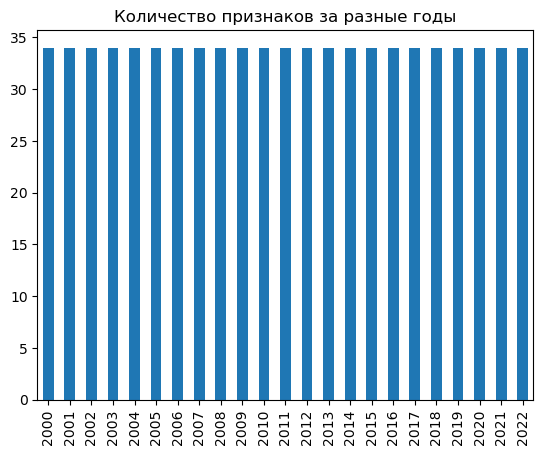

In [388]:
for key in Население.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Население[key] = new_df

total = set()
for key in Население.keys():
    total.update(set(Население[key].columns))

for key in Население.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Население[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Население[year].columns) - 3 for year in Население.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_02_socio_economic_102_v20240607 (Труд)

In [398]:
df = pd.read_excel('data_02_socio_economic_102_v20240607.xlsx')

In [399]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Труд,Y4170201000000,Численность рабочей силы,CD,Российская Федерация,страна,0,0,2000,72770.0,по данным выборочных обследований рабочей силы...,До 2017 г. обследование проводилось в отношени...,Регионы России. Социально-экономические показа...


In [400]:
needed_cols = np.array([k for k, v in df['indicator_name'].value_counts().items() if v == 2208])

In [401]:
df = df[df['indicator_name'].isin(needed_cols)]

In [402]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [403]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    assert(all([df1['year'].value_counts().values[i] == len(df1['object_name'].unique()) for i in range(len(df1['year'].value_counts().values))]))
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [404]:
df = pd.concat(dfs, axis=0)

In [405]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [406]:
# инициализируем года
Труд = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

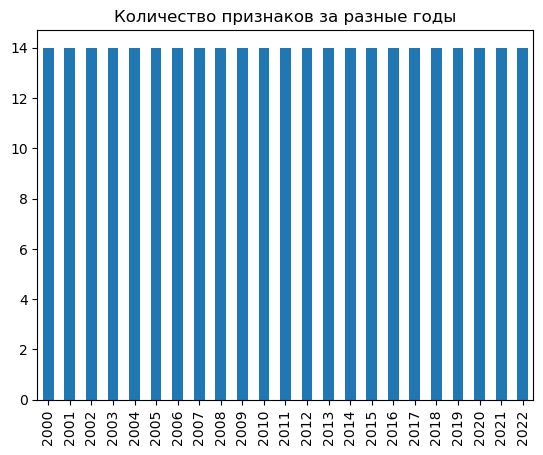

In [407]:
for key in Труд.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Труд[key] = new_df

total = set()
for key in Труд.keys():
    total.update(set(Труд[key].columns))

for key in Труд.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Труд[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Труд[year].columns) - 3 for year in Труд.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_03_socio_economic_102_v20240607 (Уровень жизни населения)

In [418]:
df = pd.read_excel('data_03_socio_economic_102_v20240607.xlsx')

In [419]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Уровень жизни населения,Y4170301010000,Реальные денежные доходы: Реальные доходы насе...,CD,Российская Федерация,страна,0,0,2000,113.4,в процентах к предыдущему году,До 2013 г. (для относительных показателей — до...,Регионы России. Социально-экономические показа...


In [420]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(df['subsection'].unique() == ['CD'])
    # оно здесь не выполнено
    print('ВЫПОЛНЕНО')
except:
    print('НЕ ВЫПОЛНЕНО')

НЕ ВЫПОЛНЕНО


In [421]:
needed_cols = np.array([k for k, v in df['indicator_name'].value_counts().items() if v >= 2093])

In [422]:
df = df[df['indicator_name'].isin(needed_cols)]
df = df[df['year'].isin(np.array(range(2000, 2023, 1)))]

In [423]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    if list(df1['subsection'].unique()) == ['CD']:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    else:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'subsection', 'year', 'indicator_value', 'indicator_unit']]
        if name == 'Реальные денежные доходы: Реальный размер назначенных пенсий':
            df1 = df1[df1['subsection'] != 'Включая единовременную выплату']
            df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
            df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
            assert(len(df1['indicator_unit'].unique()) == 1)
            dfs.append(df1)
            continue
        if name == 'Средний размер назначенных пенсий':
            df1 = df1[df1['subsection'] != 'Включая единовременную выплату']
            df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
            df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
            assert(len(df1['indicator_unit'].unique()) == 1)
            dfs.append(df1)
            continue
        if name == 'Структура денежных доходов населения':
            for i in range(4):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        if name == 'Структура социальных выплат':
            for i in range(4):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        if name == 'Структура использования денежных доходов населения':
            for i in range(5):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        if name == 'Структура потребительских расходов домашних хозяйств':
            for i in range(4):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        else:
            print(name)
            continue
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [424]:
df = pd.concat(dfs, axis=0)

In [425]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [426]:
# инициализируем года
Уровень_жизни_населения = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:
~~~ Структура денежных доходов населения: Оплата труда (в процентах от общего объема денежных доходов)
~~~ Структура денежных доходов населения: Доходы от предпринимательской деятельности (в процентах от общего объема денежных доходов)


Text(0.5, 1.0, 'Количество признаков за разные годы')

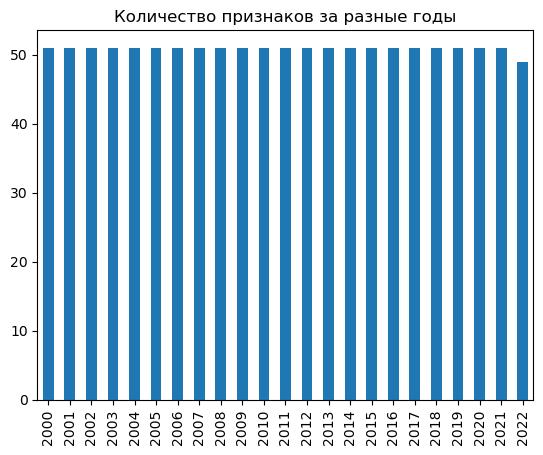

In [427]:
for key in Уровень_жизни_населения.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Уровень_жизни_населения[key] = new_df

total = set()
for key in Уровень_жизни_населения.keys():
    total.update(set(Уровень_жизни_населения[key].columns))

for key in Уровень_жизни_населения.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Уровень_жизни_населения[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Уровень_жизни_населения[year].columns) - 3 for year in Уровень_жизни_населения.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_04_socio_economic_102_v20240607 (Образование)

In [492]:
df = pd.read_excel('data_04_socio_economic_102_v20240607.xlsx')

In [493]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Образование,Y4170401000000,"Численность воспитанников организаций, осущест...",CD,Российская Федерация,страна,0,0,2000,4263.0,"на конец года, тысяч человек",Информация за 2021 год приведена с учетом инди...,Регионы России. Социально-экономические показа...


In [494]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [495]:
# оставляем только признаки реленвантные в 2000 году
needed = df[df['year'] == 2000]['indicator_name'].unique()
df = df[df['indicator_name'].isin(needed)]

In [496]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [497]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    if (len(df1['year'].unique()) == 23):
        df1 = df1[['indicator_name', 'object_name', 'year', 'indicator_value', 'indicator_unit']]
        df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] >= 0, np.nan)
        assert(sorted(df1['year'].unique()) == [i for i in range(2000, 2023, 1)])
        assert(len(df1['indicator_unit'].unique()) == 1)
        dfs.append(df1)

In [498]:
# инициализируем года
Образование = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
~~~ Численность студентов государственных и муниципальных профессиональных образовательных организаций, обучающихся по программам подготовки специалистов среднего звена на 10 000 человек населения (на начало учебного года, человек)
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

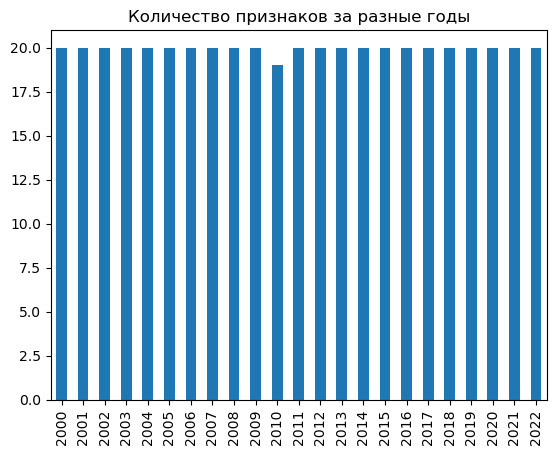

In [499]:
for key in Образование.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Образование[key] = new_df

total = set()
for key in Образование.keys():
    total.update(set(Образование[key].columns))

for key in Образование.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Образование[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Образование[year].columns) - 3 for year in Образование.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_05_socio_economic_102_v20240607 (Здравоохранение)

In [508]:
df = pd.read_excel('data_05_socio_economic_102_v20240607.xlsx')

In [509]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Здравоохранение,Y4170501010000,Число больничных коек: Всего,CD,Российская Федерация,страна,0,0,2000,1671.6,"на конец года, тысяч коек",2005 г. — включая койки дневных стационаров,Регионы России. Социально-экономические показа...


In [510]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [511]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [512]:
# инициализируем года
Здравоохранение = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
~~~ Заболеваемость на 1000 человек населения по основным классам болезней (зарегистрировано заболеваний у пациентов с диагнозом, установленным впервые в жизни)
~~~ Заболеваемость на 1000 человек населения по основным классам болезней: Некоторые инфекционные и паразитарные болезни (зарегистрировано заболеваний у пациентов с диагнозом, установленным впервые в жизни)
~~~ Заболеваемость на 1000 человек населения по основным классам болезней: Травмы, отравления и некоторые другие последствия воздействия внешних причин (зарегистрировано заболеваний у пациентов с диагнозом, установленным впервые в жизни)
~~~ Заболеваемость на 1000 человек населения по основным классам болезней: Болезни мочеполовой системы (зарегистрировано заболеваний у пациентов с диагнозом, установленным впервые в жизни)
~~~ Заболеваемость на 1000 человек населения по основным классам болезней: Болезни крови, кроветворных органов и отдельные нарушения, вовлекающие иммунный механизм (зарегистрировано з

Text(0.5, 1.0, 'Количество признаков за разные годы')

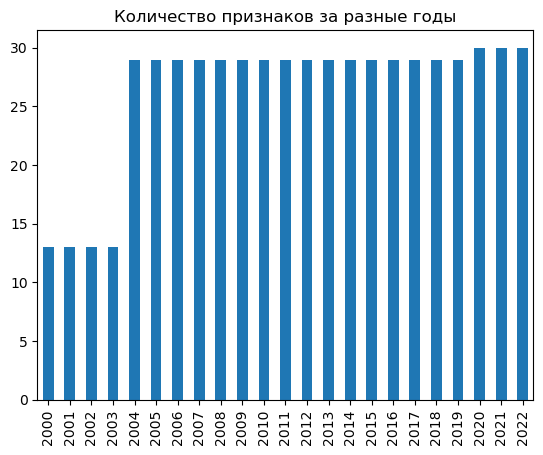

In [513]:
for key in Здравоохранение.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Здравоохранение[key] = new_df

total = set()
for key in Здравоохранение.keys():
    total.update(set(Здравоохранение[key].columns))

for key in Здравоохранение.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Здравоохранение[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Здравоохранение[year].columns) - 3 for year in Здравоохранение.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_06_socio_economic_102_v20240607 (Культура, отдых и туризм)

In [520]:
df = pd.read_excel('data_06_socio_economic_102_v20240607.xlsx')

In [521]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,"Культура, отдых и туризм",Y4170601010000,Численность зрителей театров и число посещений...,CD,Российская Федерация,страна,0,0,2000,210.0,человек,Расчет осуществлен на основе данных Минкультур...,Регионы России. Социально-экономические показа...


In [522]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [523]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [524]:
# инициализируем года
Культура_отдых_и_туризм = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
~~~ Туристские фирмы: Число турпакетов, реализованных населению (тысяч)
~~~ Численность российских туристов, обслуженных туристскими фирмами: Численность российских туристов, отправленных туристскими фирмами, в зарубежные туры (тысяч человек)
~~~ Численность отдохнувших детей в субъекте Российской Федерации (тысяч человек)
~~~ Численность российских туристов, обслуженных туристскими фирмами: Численность российских туристов, отправленных туристскими фирмами, в туры по России (тысяч человек)
~~~ Туристские фирмы: Число туристских фирм (ND)
В 2001 году не учлись:
~~~ Туристские фирмы: Число турпакетов, реализованных населению (тысяч)
~~~ Численность российских туристов, обслуженных туристскими фирмами: Численность российских туристов, отправленных туристскими фирмами, в зарубежные туры (тысяч человек)
~~~ Численность отдохнувших детей в субъекте Российской Федерации (тысяч человек)
~~~ Численность российских туристов, обслуженных туристскими фирмами: Численность рос

Text(0.5, 1.0, 'Количество признаков за разные годы')

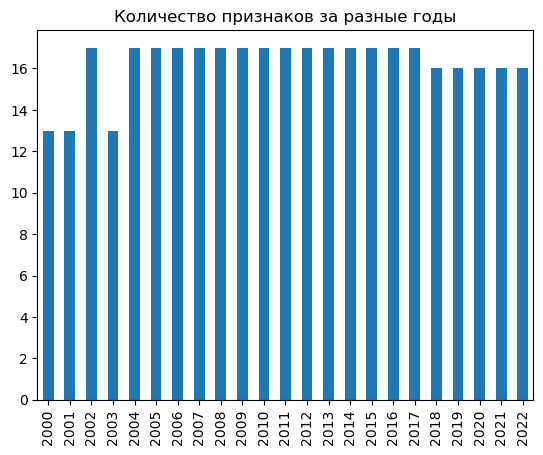

In [525]:
for key in Культура_отдых_и_туризм.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Культура_отдых_и_туризм[key] = new_df

total = set()
for key in Культура_отдых_и_туризм.keys():
    total.update(set(Культура_отдых_и_туризм[key].columns))

for key in Культура_отдых_и_туризм.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Культура_отдых_и_туризм[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Культура_отдых_и_туризм[year].columns) - 3 for year in Культура_отдых_и_туризм.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_07_socio_economic_102_v20240607 (Земельные ресурсы и охрана окружающей природной среды)

In [541]:
df = pd.read_excel('data_07_socio_economic_102_v20240607.xlsx')

In [543]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Земельные ресурсы и охрана окружающей природно...,Y4170701010000,Земельная площадь по видам угодий: Сельскохозя...,CD,Российская Федерация,страна,0,0,2005,220.7,"на конец года, тысяч га; для значений в целом ...",По данным Федеральной службы государственной р...,Регионы России. Социально-экономические показа...


In [551]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [553]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [561]:
# инициализируем года
Земля_и_охрана_природы = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
~~~ Земельная площадь по видам угодий: Лесные земли (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Сельскохозяйственные угодья (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Сельскохозяйстве (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Поверхностные воды, включая болота (на конец года, тысяч га; для значений в целом по России: млн га)
В 2001 году не учлись:
~~~ Земельная площадь по видам угодий: Лесные земли (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Сельскохозяйственные угодья (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Сельскохозяйстве (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Поверхностные воды, включая б

Text(0.5, 1.0, 'Количество признаков за разные годы')

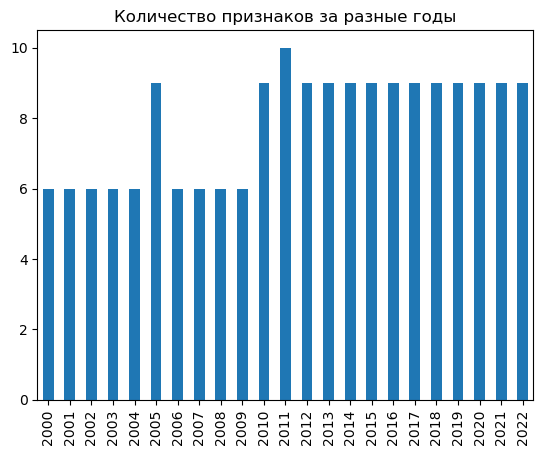

In [567]:
for key in Земля_и_охрана_природы.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Земля_и_охрана_природы[key] = new_df

total = set()
for key in Земля_и_охрана_природы.keys():
    total.update(set(Земля_и_охрана_природы[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Земля_и_охрана_природы[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Земля_и_охрана_природы[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_08_socio_economic_102_v20240607 (Валовой региональный продукт)

In [579]:
df = pd.read_excel('data_08_socio_economic_102_v20240607.xlsx')

In [580]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Валовой региональный продукт,Y4170801000000,Валовой региональный продукт,CD,Российская Федерация,страна,0,0,2000,5753671.6,миллионов рублей,CD,Регионы России. Социально-экономические показа...


In [590]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [592]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [612]:
# инициализируем года
ВРП = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 2017 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 2018 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 2019 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 2020 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 

Text(0.5, 1.0, 'Количество признаков за разные годы')

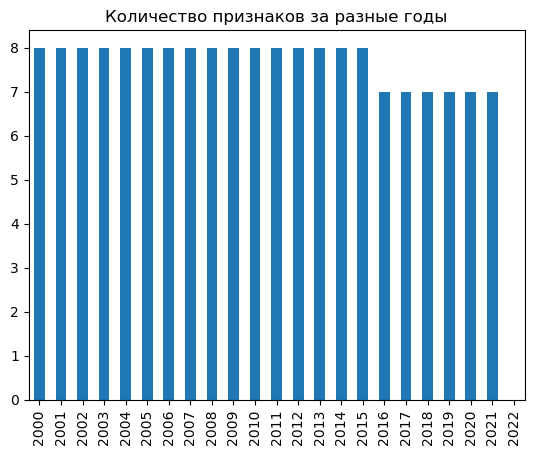

In [618]:
for key in ВРП.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    ВРП[key] = new_df

total = set()
for key in ВРП.keys():
    total.update(set(ВРП[key].columns))

for key in range(2000, 2023):
    if key == 2022:
        continue
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(ВРП[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(ВРП[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_09_socio_economic_102_v20240607 (Основные фонды)

In [637]:
df = pd.read_excel('data_09_socio_economic_102_v20240607.xlsx')

In [638]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Основные фонды,Y4170901000000,Стоимость основных фондов,CD,Российская Федерация,страна,0,0,2000,17464172.0,"на конец года, по полной учетной стоимости, ми...",С учетом проводившихся переоценок,Регионы России. Социально-экономические показа...


In [639]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [640]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [645]:
# инициализируем года
Основные_фонды = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:
~~~ Удельный вес полностью изношенных основных фондов в их общем объеме в 2000‒2021 гг. (на конец года, по полной учетной стоимости, в процентах)


Text(0.5, 1.0, 'Количество признаков за разные годы')

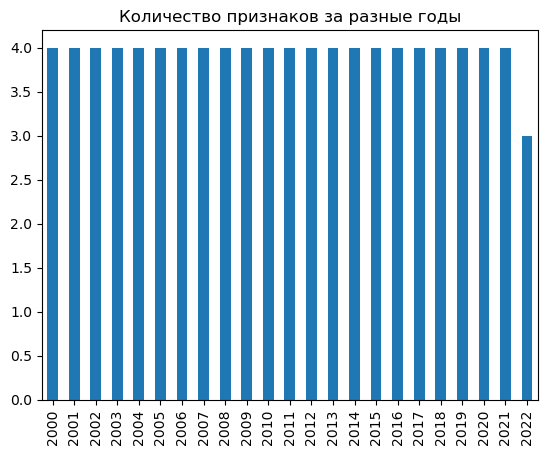

In [649]:
for key in Основные_фонды.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Основные_фонды[key] = new_df

total = set()
for key in Основные_фонды.keys():
    total.update(set(Основные_фонды[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Основные_фонды[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Основные_фонды[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_10_socio_economic_102_v20240607 (Инвестиции)

In [667]:
df = pd.read_excel('data_10_socio_economic_102_v20240607.xlsx')

In [668]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Инвестиции,Y4171001000000,Инвестиции в основной капитал,CD,Российская Федерация,страна,0,0,2000,1165234.0,"в фактически действовавших ценах, миллионов ру...",2022 г. — включая уточнение на федеральном уро...,Регионы России. Социально-экономические показа...


In [671]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [673]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [679]:
# инициализируем года
Инвестиции = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
~~~ Поступление прямых иностранных инвестиций в российскую федерацию: Изъято (по данным платежного баланса Российской Федерации, миллионов долларов США)
~~~ Поступление прямых иностранных инвестиций в российскую федерацию: Сальдо (по данным платежного баланса Российской Федерации, миллионов долларов США)
~~~ Поступление прямых иностранных инвестиций в российскую федерацию: Поступило (по данным платежного баланса Российской Федерации, миллионов долларов США)
В 2001 году не учлись:
~~~ Поступление прямых иностранных инвестиций в российскую федерацию: Изъято (по данным платежного баланса Российской Федерации, миллионов долларов США)
~~~ Поступление прямых иностранных инвестиций в российскую федерацию: Сальдо (по данным платежного баланса Российской Федерации, миллионов долларов США)
~~~ Поступление прямых иностранных инвестиций в российскую федерацию: Поступило (по данным платежного баланса Российской Федерации, миллионов долларов США)
В 2002 году не учлись:
~~~ Пос

Text(0.5, 1.0, 'Количество признаков за разные годы')

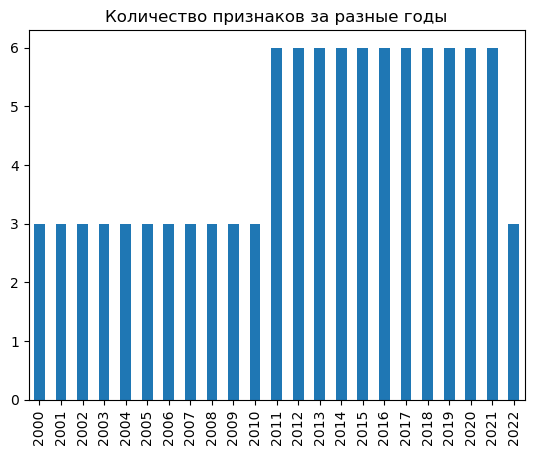

In [681]:
for key in Инвестиции.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Инвестиции[key] = new_df

total = set()
for key in Инвестиции.keys():
    total.update(set(Инвестиции[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Инвестиции[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Инвестиции[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_11_socio_economic_102_v20240607 (Предприятия и организации)

In [759]:
df = pd.read_excel('data_11_socio_economic_102_v20240607.xlsx')

In [760]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Предприятия и организации,Y4171101000000,Число организаций,CD,Российская Федерация,страна,0,0,2000,3346483.0,на конец года,По данным государственной регистрации,Регионы России. Социально-экономические показа...


In [761]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [46]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [763]:
# инициализируем года
Предприятия_и_организации = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

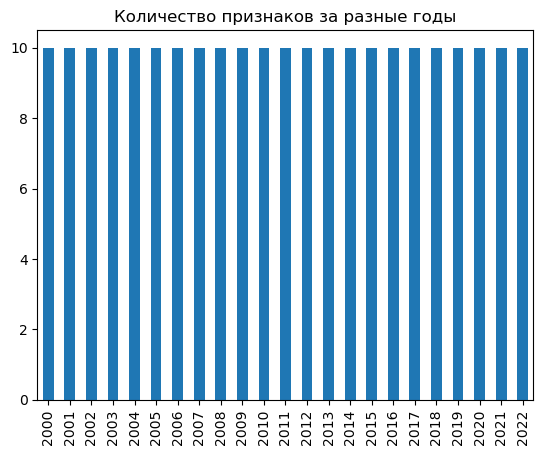

In [764]:
for key in Предприятия_и_организации.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Предприятия_и_организации[key] = new_df


#########################
# сразу выбираем только те признаки, которые есть для всех годов
total = set()
for key in Предприятия_и_организации.keys():
    total.update(set(Предприятия_и_организации[key].columns))

for key in range(2000, 2023):
    total = total.intersection(set(Предприятия_и_организации[key].columns))
total = np.array(list(total))

for key in range(2000, 2023):
    buff_df = pd.DataFrame()
    buff_df['object_name'] = Предприятия_и_организации[key]['object_name']
    buff_df['object_level'] = Предприятия_и_организации[key]['object_level']
    buff_df['year'] = Предприятия_и_организации[key]['year']

    for feature in sorted(total):
        buff_df[feature] = Предприятия_и_организации[key][feature]
    
    Предприятия_и_организации[key] = buff_df
#########################


total = set()
for key in Предприятия_и_организации.keys():
    total.update(set(Предприятия_и_организации[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Предприятия_и_организации[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Предприятия_и_организации[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_12_socio_economic_102_v20240607 (НЕ СФОРМИРОВАНО - Промышленное производство)

# data_13_socio_economic_102_v20240607 (Сельское, лесное хозяйство, рыболовство и рыбоводство)

In [28]:
df = pd.read_excel('data_13_socio_economic_102_v20240607.xlsx')

In [34]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,"Сельское, лесное хозяйство, рыболовство и рыбо...",Y4171301000000,Продукция сельского хозяйства,CD,Российская Федерация,страна,0,0,2000,742424.398,"в хозяйствах всех категорий, в фактически дейс...",Изменения внесены в связи с получением итогов ...,Регионы России. Социально-экономические показа...


In [44]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [50]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [60]:
Сельхоз_и_рыболовство = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

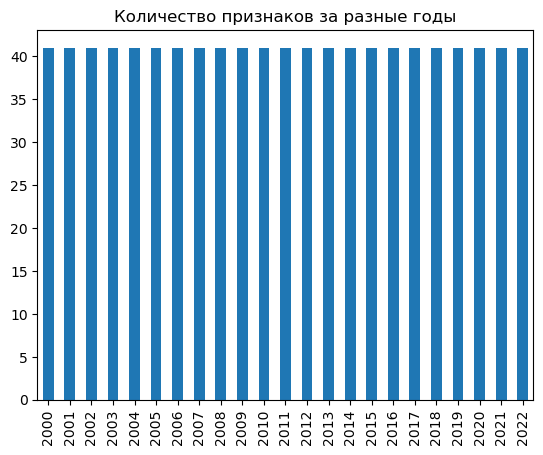

In [65]:
for key in Сельхоз_и_рыболовство.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Сельхоз_и_рыболовство[key] = new_df


#########################
# сразу выбираем только те признаки, которые есть для всех годов
total = set()
for key in Сельхоз_и_рыболовство.keys():
    total.update(set(Сельхоз_и_рыболовство[key].columns))

for key in range(2000, 2023):
    total = total.intersection(set(Сельхоз_и_рыболовство[key].columns))
total = np.array(list(total))

for key in range(2000, 2023):
    buff_df = pd.DataFrame()
    buff_df['object_name'] = Сельхоз_и_рыболовство[key]['object_name']
    buff_df['object_level'] = Сельхоз_и_рыболовство[key]['object_level']
    buff_df['year'] = Сельхоз_и_рыболовство[key]['year']

    for feature in sorted(total):
        buff_df[feature] = Сельхоз_и_рыболовство[key][feature]
    
    Сельхоз_и_рыболовство[key] = buff_df
#########################


total = set()
for key in Сельхоз_и_рыболовство.keys():
    total.update(set(Сельхоз_и_рыболовство[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Сельхоз_и_рыболовство[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Сельхоз_и_рыболовство[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_14_socio_economic_102_v20240607 (Строительство)

In [75]:
df = pd.read_excel('data_14_socio_economic_102_v20240607.xlsx')

In [84]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Строительство,Y4171401000000,"Объем работ, выполненных по виду экономической...",CD,Российская Федерация,страна,0,0,2000,503836.8,"в фактически действовавших ценах, миллионов ру...",2022 г. — сводные итоги по Российской Федераци...,Регионы России. Социально-экономические показа...


In [156]:
# если не выполнено, то требуется ручная обработка
try:
    assert(df['subsection'].unique() == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНО!!!")

НЕ ВЫПОЛНЕНО!!!


In [90]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [108]:
df = df[df['indicator_name'] != 'Число зданий и сооружений, находящихся в незавершенном строительстве']

In [110]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    if list(df1['subsection'].unique()) == ['CD']:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    else:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'subsection', 'year', 'indicator_value', 'indicator_unit']]
        if name == 'Жилые дома, находящиеся в незавершенном строительстве':
            for i in range(2):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        else:
            print(name)
            continue
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [142]:
df = pd.concat(dfs, axis=0)

In [144]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [146]:
# инициализируем года
Строительство = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

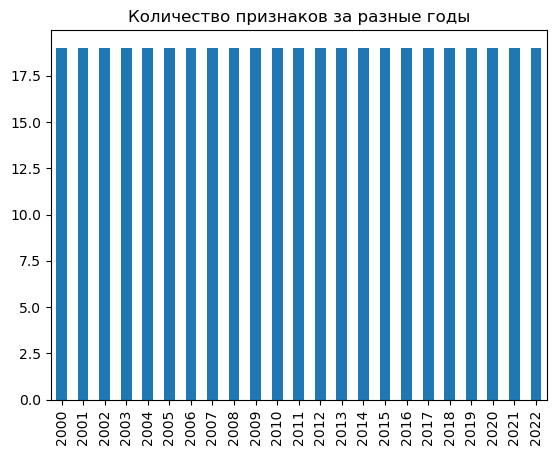

In [148]:
for key in Строительство.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Строительство[key] = new_df

total = set()
for key in Строительство.keys():
    total.update(set(Строительство[key].columns))

for key in Строительство.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Строительство[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Строительство[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_15_socio_economic_102_v20240607 (Торговля и услуги населению)

In [165]:
df = pd.read_excel('data_15_socio_economic_102_v20240607.xlsx')

In [176]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Торговля и услуги населению,Y4171501000000,Оборот розничной торговли,CD,Российская Федерация,страна,0,0,2000,2352.3,"в фактически действовавших ценах, миллионов ру...",CD,Регионы России. Социально-экономические показа...


In [178]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [182]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [192]:
Торговля_и_услуги_населению = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

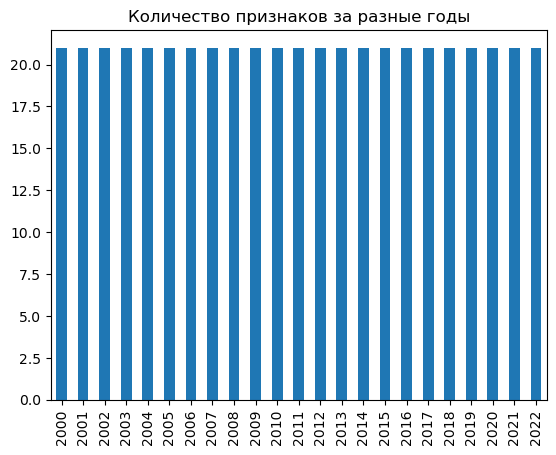

In [194]:
for key in Торговля_и_услуги_населению.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Торговля_и_услуги_населению[key] = new_df


#########################
# сразу выбираем только те признаки, которые есть для всех годов
total = set()
for key in Торговля_и_услуги_населению.keys():
    total.update(set(Торговля_и_услуги_населению[key].columns))

for key in range(2000, 2023):
    total = total.intersection(set(Торговля_и_услуги_населению[key].columns))
total = np.array(list(total))

for key in range(2000, 2023):
    buff_df = pd.DataFrame()
    buff_df['object_name'] = Торговля_и_услуги_населению[key]['object_name']
    buff_df['object_level'] = Торговля_и_услуги_населению[key]['object_level']
    buff_df['year'] = Торговля_и_услуги_населению[key]['year']

    for feature in sorted(total):
        buff_df[feature] = Торговля_и_услуги_населению[key][feature]
    
    Торговля_и_услуги_населению[key] = buff_df
#########################


total = set()
for key in Торговля_и_услуги_населению.keys():
    total.update(set(Торговля_и_услуги_населению[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Торговля_и_услуги_населению[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Торговля_и_услуги_населению[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_16_socio_economic_102_v20240607 (Транспорт)

In [225]:
df = pd.read_excel('data_16_socio_economic_102_v20240607.xlsx')

In [226]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2000,1046.794,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...
1,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2001,1057.516,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...
2,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2002,1083.700,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...
3,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2003,1160.934,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...
4,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2004,1221.164,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...


In [227]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [228]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [229]:
Транспорт = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

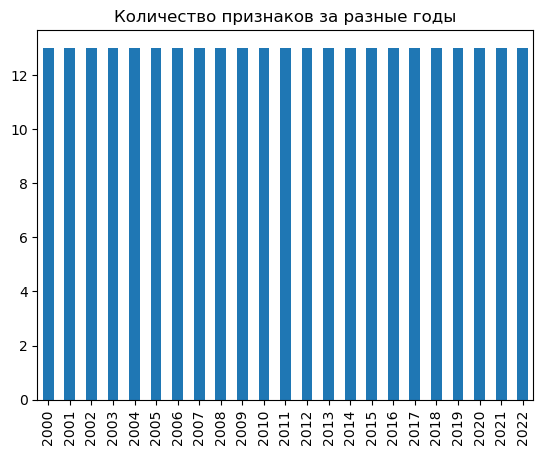

In [230]:
for key in Транспорт.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Транспорт[key] = new_df


#########################
# # сразу выбираем только те признаки, которые есть для всех годов
# total = set()
# for key in Транспорт.keys():
#     total.update(set(Транспорт[key].columns))

# for key in range(2000, 2023):
#     total = total.intersection(set(Транспорт[key].columns))
# total = np.array(list(total))

# for key in range(2000, 2023):
#     buff_df = pd.DataFrame()
#     buff_df['object_name'] = Транспорт[key]['object_name']
#     buff_df['object_level'] = Транспорт[key]['object_level']
#     buff_df['year'] = Транспорт[key]['year']

#     for feature in sorted(total):
#         buff_df[feature] = Транспорт[key][feature]
    
#     Транспорт[key] = buff_df
# #########################


total = set()
for key in Транспорт.keys():
    total.update(set(Транспорт[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Транспорт[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Транспорт[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_17_socio_economic_102_v20240607 (НЕ СФОРМИРОВАНО - Информационные и коммуникационные технологии)

# data_18_socio_economic_102_v20240607 (Наука и инновации)

In [296]:
df = pd.read_excel('data_18_socio_economic_102_v20240607.xlsx')

In [297]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2000,4099.0,ND,CD,Регионы России. Социально-экономические показа...
1,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2001,4037.0,ND,CD,Регионы России. Социально-экономические показа...
2,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2002,3906.0,ND,CD,Регионы России. Социально-экономические показа...
3,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2003,3797.0,ND,CD,Регионы России. Социально-экономические показа...
4,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2004,3656.0,ND,CD,Регионы России. Социально-экономические показа...


In [298]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(list(df['subsection'].unique()) == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНЕНО!!!")

НЕ ВЫПОЛНЕНЕНО!!!


In [299]:
df = df[df['subsection'] == 'CD']
df = df[df['indicator_name'] != 'Инновационная активность организации: Уровень инновационной активности организаций']
df = df[df['indicator_name'] != 'Инновационная активность организаций: Удельный вес организаций, осуществлявших технологические инновации, в общем числе обследованных организаций']

In [306]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [308]:
Наука_и_инновации = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

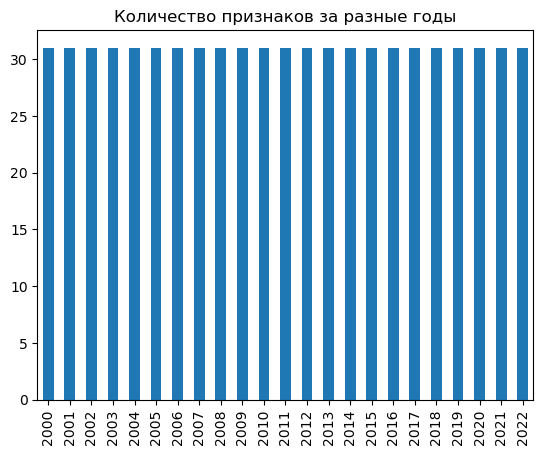

In [310]:
for key in Наука_и_инновации.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Наука_и_инновации[key] = new_df


#########################
# # сразу выбираем только те признаки, которые есть для всех годов
# total = set()
# for key in Наука_и_инновации.keys():
#     total.update(set(Наука_и_инновации[key].columns))

# for key in range(2000, 2023):
#     total = total.intersection(set(Наука_и_инновации[key].columns))
# total = np.array(list(total))

# for key in range(2000, 2023):
#     buff_df = pd.DataFrame()
#     buff_df['object_name'] = Наука_и_инновации[key]['object_name']
#     buff_df['object_level'] = Наука_и_инновации[key]['object_level']
#     buff_df['year'] = Наука_и_инновации[key]['year']

#     for feature in sorted(total):
#         buff_df[feature] = Наука_и_инновации[key][feature]
    
#     Наука_и_инновации[key] = buff_df
# #########################


total = set()
for key in Наука_и_инновации.keys():
    total.update(set(Наука_и_инновации[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Наука_и_инновации[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Наука_и_инновации[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_19_socio_economic_102_v20240607 (Финансы - но это не "та самая" часть)

In [319]:
df = pd.read_excel('data_19_socio_economic_102_v20240607.xlsx')

In [323]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Ро...,CD,Российская Федерация,страна,0,0,2000,1065.8,миллионов рублей; для значений в целом по Росс...,По данным Федерального казначейства,Регионы России. Социально-экономические показа...
1,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Ро...,CD,Российская Федерация,страна,0,0,2001,1322.4,миллионов рублей; для значений в целом по Росс...,По данным Федерального казначейства,Регионы России. Социально-экономические показа...
2,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Ро...,CD,Российская Федерация,страна,0,0,2002,1633.6,миллионов рублей; для значений в целом по Росс...,По данным Федерального казначейства,Регионы России. Социально-экономические показа...
3,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Ро...,CD,Российская Федерация,страна,0,0,2003,1930.5,миллионов рублей; для значений в целом по Росс...,По данным Федерального казначейства,Регионы России. Социально-экономические показа...
4,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Ро...,CD,Российская Федерация,страна,0,0,2004,2403.2,миллионов рублей; для значений в целом по Росс...,По данным Федерального казначейства,Регионы России. Социально-экономические показа...


In [329]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(list(df['subsection'].unique()) == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНЕНО!!!")

ВЫПОЛНЕНО


In [331]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [342]:
Финансы = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
~~~ Отдельные показатели деятельности страховщиков, исходя из места заключения договора: Выплаты по договорам страхования (миллионов рублей)
~~~ Задолженность по кредитам в иностранной валюте, предоставленным кредитными организациями физическим лицам: По ипотечным жилищным кредитам (исходя из местонахождения заемщиков, на начало года, миллионов рублей)
~~~ Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам: По жилищным кредитам (исходя из местонахождения заемщиков, на начало года, миллионов рублей)
~~~ Отдельные показатели деятельности страховщиков, исходя из места заключения договора: Страховые премии (взносы) (миллионов рублей)
~~~ Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам: По ипотечным жилищным кредитам (исходя из местонахождения заемщиков, на начало года, миллионов рублей)
~~~ Расходы консолидированных бюджетов субъектов Российской Федерации на реализацию мер социал

Text(0.5, 1.0, 'Количество признаков за разные годы')

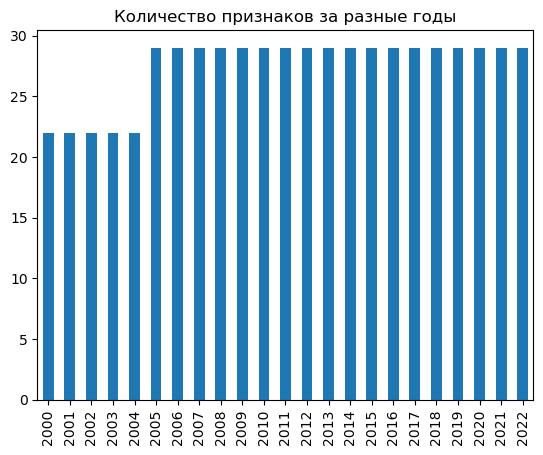

In [344]:
for key in Финансы.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Финансы[key] = new_df


#########################
# # сразу выбираем только те признаки, которые есть для всех годов
# total = set()
# for key in Финансы.keys():
#     total.update(set(Финансы[key].columns))

# for key in range(2000, 2023):
#     total = total.intersection(set(Финансы[key].columns))
# total = np.array(list(total))

# for key in range(2000, 2023):
#     buff_df = pd.DataFrame()
#     buff_df['object_name'] = Финансы[key]['object_name']
#     buff_df['object_level'] = Финансы[key]['object_level']
#     buff_df['year'] = Финансы[key]['year']

#     for feature in sorted(total):
#         buff_df[feature] = Финансы[key][feature]
    
#     Финансы[key] = buff_df
# #########################


total = set()
for key in Финансы.keys():
    total.update(set(Финансы[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Финансы[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Финансы[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_20_socio_economic_102_v20240607 (Цены и тарифы)

In [484]:
df = pd.read_excel('data_20_socio_economic_102_v20240607.xlsx')

In [485]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2000,120.2,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...
1,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2001,118.6,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...
2,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2002,115.1,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...
3,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2003,112.0,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...
4,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2004,111.7,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...


In [486]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(list(df['subsection'].unique()) == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНЕНО!!!")

ВЫПОЛНЕНО


In [487]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [498]:
neeeded = df['indicator_name'].value_counts()[df['indicator_name'].value_counts() >= 2208].index
df = df[df['indicator_name'].isin(neeeded)]

In [502]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    if len(list(df1['indicator_unit'].unique())) == 1:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    else:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
        if name == 'Стоимость фиксированного набора потребительских товаров и услуг: Стоимость фиксированного набора':
            for i in range(2):
                df0 = df1[df1['indicator_unit'] == df1['indicator_unit'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + f' (option_{i})'
                dfs.append(df0)
            continue
        if name == 'Стоимость условного (минимального) набора продуктов питания: Стоимость минимального набора':
            for i in range(2):
                df0 = df1[df1['indicator_unit'] == df1['indicator_unit'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + f' (option_{i})'
                dfs.append(df0)
            continue
        else:
            print(name)
            continue
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [504]:
df = pd.concat(dfs, axis=0)

In [506]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [508]:
Цены_и_тарифы = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

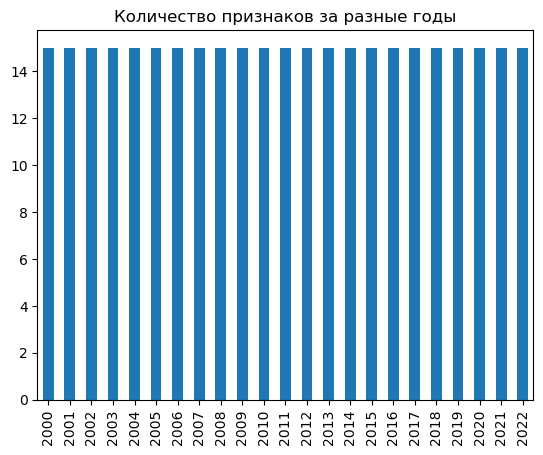

In [510]:
for key in Цены_и_тарифы.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Цены_и_тарифы[key] = new_df

total = set()
for key in Цены_и_тарифы.keys():
    total.update(set(Цены_и_тарифы[key].columns))

for key in Цены_и_тарифы.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Цены_и_тарифы[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Цены_и_тарифы[year].columns) - 3 for year in Цены_и_тарифы.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_21_socio_economic_102_v20240607 (Внешняя торговля)

In [3]:
df = pd.read_excel('data_21_socio_economic_102_v20240607.xlsx')

In [4]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2000,89269.2,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...
1,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2001,85352.2,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...
2,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2002,90545.5,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...
3,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2003,113157.0,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...
4,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2004,152248.0,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...


In [5]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(list(df['subsection'].unique()) == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНЕНО!!!")

ВЫПОЛНЕНО


In [6]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [7]:
Внешняя_торговля = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:
~~~ Внешняя торговля со странами дальнего зарубежья: Импорт (в фактически действовавших ценах, миллионов долларов США)
~~~ Внешняя торговля со странами СНГ: Экспорт (в фактически действовавших ценах, миллионов долларов США)
~~~ Внешняя торговля со странами дальнего зарубежья: Экспорт (в фактически действовавших ценах, миллионов долларов США)
~~~ Внешняя торговля со странами СНГ: Импорт (в фактически действовавших ценах, миллионов долларов США)


Text(0.5, 1.0, 'Количество признаков за разные годы')

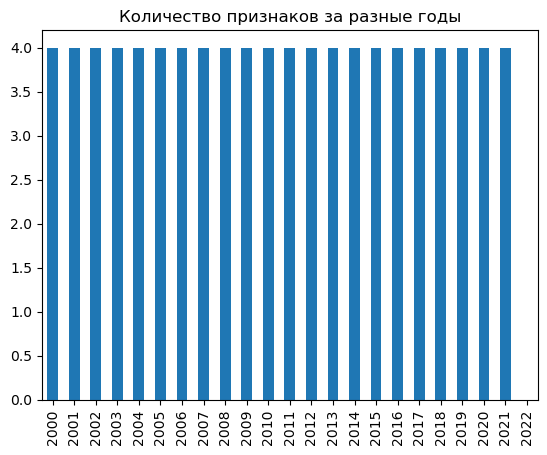

In [8]:
for key in Внешняя_торговля.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    Внешняя_торговля[key] = new_df


#########################
# # сразу выбираем только те признаки, которые есть для всех годов
# total = set()
# for key in Внешняя_торговля.keys():
#     total.update(set(Внешняя_торговля[key].columns))

# for key in range(2000, 2023):
#     total = total.intersection(set(Внешняя_торговля[key].columns))
# total = np.array(list(total))

# for key in range(2000, 2023):
#     buff_df = pd.DataFrame()
#     buff_df['object_name'] = Внешняя_торговля[key]['object_name']
#     buff_df['object_level'] = Внешняя_торговля[key]['object_level']
#     buff_df['year'] = Внешняя_торговля[key]['year']

#     for feature in sorted(total):
#         buff_df[feature] = Внешняя_торговля[key][feature]
    
#     Внешняя_торговля[key] = buff_df
# #########################


total = set()
for key in Внешняя_торговля.keys():
    total.update(set(Внешняя_торговля[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Внешняя_торговля[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Внешняя_торговля[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# PREPROCESSING